# Milestone 5 — Final evaluation on the reserved historical period
**Joel Cerraga · Market-Neutral Trading Algorithm**

The frozen design compares the existing primary graph strategy with the baseline on 2020–2025. It keeps all 22 declared cases and transfers the topology controls without refitting. No topology trading overlay is introduced. The test is now observed; future rule changes need new evidence.

As White (2000) explains in *A Reality Check for Data Snooping*, searching over alternatives changes the meaning of apparent success. Bailey et al. (2017), in *The probability of backtest overfitting*, also discuss repeated selection. This project therefore records the finite comparison and necessary evidence conditions before acquisition. It does not claim to implement either paper's complete correction.

“Reserved” describes this project's chronology. The years are public history and the basket contains retrospectively selected survivors. As Shumway (1997) explains in *The Delisting Bias in CRSP Data*, missing adverse outcomes matter for historical inference. That limitation is not removed by a protocol hash. Final PDF compilation remains deferred.

In [1]:
from pathlib import Path
import json, sys, inspect
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if not (ROOT / "market_neutral").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from market_neutral.historical import sha256
from market_neutral.final_data import load_final_protocol, assemble_final_dataset, overlap_audit
from market_neutral.final_evaluation import evaluate_final, final_topology
from market_neutral.final_inference import fixed_family_intervals
from market_neutral.final_plots import create_final_figures
output = ROOT / "outputs/final"
print("Working folder:", ROOT.name)

Working folder: Market-Neutral-Trading-Algorithm


## 1. Verify the protocol and separate observation vintage

Yahoo Finance (2026b) supplies the requested final vintage. The old cache remains unchanged. Each series must have the exact SPY calendar, positive complete observations and no return above the predeclared review threshold. The new warm-up is not spliced into the old adjusted-price series.

Equation 28 compares overlapping **returns**, permitting a constant adjustment factor while rejecting material revisions:

$$\max_{t\in\mathcal O}|r_t^{\mathrm{new}}-r_t^{\mathrm{old}}|\leq 10^{-5}.\tag{28}$$

The tolerance is 0.1 basis points, fixed before acquisition. The retained snapshot guard fixes the audited vintage for subsequent replay; its recording time is separate from the earlier design lock.

In [2]:
protocol = load_final_protocol(ROOT)
dataset, audit = assemble_final_dataset(ROOT)
lock = json.loads((ROOT / "protocol/final-evaluation-v1.lock.json").read_text())
release = json.loads((output / "holdout-release.json").read_text())
assert pd.Timestamp(lock["locked_utc"]) < pd.Timestamp(release["release_started_utc"])
assert audit.rows.eq(1761).all() and audit.overlap_returns.eq(252).all()
assert audit.max_abs_overlap_return_change.max() <= 1e-5
print("Final design hash:", dataset.metadata["protocol_sha256"])
print("Audited input hash:", dataset.metadata["input_sha256"])
print("Largest overlapping return change, basis points:", 10000*audit.max_abs_overlap_return_change.max())
display(audit[["rows", "first_date", "last_date", "missing", "max_abs_overlap_return_change"]])
print(inspect.getsource(overlap_audit))

Final design hash: 8fdee505de9ceaa8e4a2951deba29c1305eb12ee64d2d42467a978e2805c2acd
Audited input hash: 040f3199669d24009b848b5d1112321a70b7cb8084cb84fce6d6878a33abdcdd
Largest overlapping return change, basis points: 0.011536441563153588
def overlap_audit(original, latest, tolerance):
    """Return-space audit permits a constant adjustment factor, never a splice."""
    if not original.index.equals(latest.index):
        raise ValueError("Warm-up overlap calendars differ")
    old = original.pct_change(fill_method=None).iloc[1:]
    new = latest.pct_change(fill_method=None).iloc[1:]
    difference = (new - old).abs()
    maximum = float(difference.max())
    ratios = latest / original
    result = {"overlap_returns": len(difference), "max_abs_overlap_return_change": maximum,
              "median_adjusted_price_ratio": float(ratios.median()),
              "min_adjusted_price_ratio": float(ratios.min()), "max_adjusted_price_ratio": float(ratios.max())}
    if not np.isfinite(differenc

,rows,first_date,last_date,missing,max_abs_overlap_return_change
ticker,,,,,
AAPL,1761,2018-12-31,2025-12-31,0,7.531946e-07
MSFT,1761,2018-12-31,2025-12-31,0,1.052057e-06
IBM,1761,2018-12-31,2025-12-31,0,5.634729e-07
ORCL,1761,2018-12-31,2025-12-31,0,7.374924e-07
JPM,1761,2018-12-31,2025-12-31,0,6.796481e-07
BAC,1761,2018-12-31,2025-12-31,0,7.172929e-07
WFC,1761,2018-12-31,2025-12-31,0,6.604194e-07
GS,1761,2018-12-31,2025-12-31,0,7.214672e-07
XOM,1761,2018-12-31,2025-12-31,0,8.047438e-07


## 2. Replay every scenario and verify the artifact repair

The decision at close t executes at close t+1. A flat USD 100,000 book starts the final phase; entry, drift trades, calendar-day borrow and terminal liquidation are included. Calendar years do not reset positions. The finite set contains 16 model/fee cases, four extra borrow cases and two matched-gross cases.

The first run exposed a genuine artifact failure: one 10 bps graph ledger was empty. Its in-memory summary was present. The original manifest is preserved, and verified atomic writes now check the saved bytes. Every unaffected numerical output must reproduce its original hash; the repaired ledger must reconcile with the unchanged summary. Later executions require every current numeric output to reproduce too.

In [3]:
initial = json.loads((ROOT / "validation/final-initial-run-manifest.json").read_text())
repair_path = ROOT / "validation/final-artifact-repair.json"
repair = json.loads(repair_path.read_text())
previous = json.loads((output / "run-manifest.json").read_text())
was_repaired = repair["status"] == "verified"
results, summary, intervals, manifest = evaluate_final(ROOT, dataset)
affected = repair["affected_output"]
assert set(initial["files"]) == set(manifest["files"])
for name, expected in initial["files"].items():
    if name != affected:
        assert manifest["files"][name] == expected, name
if was_repaired:
    assert manifest["files"] == previous["files"]
repaired_ledger = pd.read_csv(output / affected, index_col=0, parse_dates=True)
recorded = summary.loc[(summary.model == "graph_tau_1") &
                       (summary.trading_cost_bps == 10) & (summary.annual_borrow_rate == .02)].iloc[0]
assert len(repaired_ledger) == 1508
np.testing.assert_allclose((1+repaired_ledger.net_return).prod()-1, recorded.total_return, atol=1e-11)
repair.update(status="verified", unaffected_hashes_reproduced=len(initial["files"])-1,
              repaired_rows=len(repaired_ledger), repaired_sha256=sha256(output / affected),
              summary_sha256_unchanged=manifest["files"]["final-summary.csv"],
              final_protocol_sha256=manifest["protocol_sha256"])
repair_path.write_text(json.dumps(repair, indent=2)+"\n")
create_final_figures(ROOT)
assert len(summary) == 22 and manifest["test_sessions"] == 1508
print("All 22 cases completed; initial unaffected hashes reproduced:", len(initial["files"])-1)
print("Repaired ledger:", len(repaired_ledger), "sessions; original summary unchanged")

All 22 cases completed; initial unaffected hashes reproduced: 47
Repaired ledger: 1508 sessions; original summary unchanged


## 3. Inspect absolute performance before relative improvement

Both primary strategies lose money at default costs. The graph loses less, but its negative CAGR does not meet the predeclared profitability condition. The flat line is a no-trade **zero-cash-rate** comparator consistent with the ledger, not a historical risk-free return series.

Estimated dollar/beta neutrality is a portfolio constraint. The realised rolling beta below is an empirical diagnostic and need not equal zero.

,annualised_return,total_return,annualised_volatility,maximum_drawdown,realized_market_beta,mean_gross_exposure
model,,,,,,
baseline,-0.055661,-0.290158,0.059681,-0.316939,0.032981,0.661242
graph_tau_1,-0.048041,-0.255186,0.046555,-0.286085,0.031513,0.634784


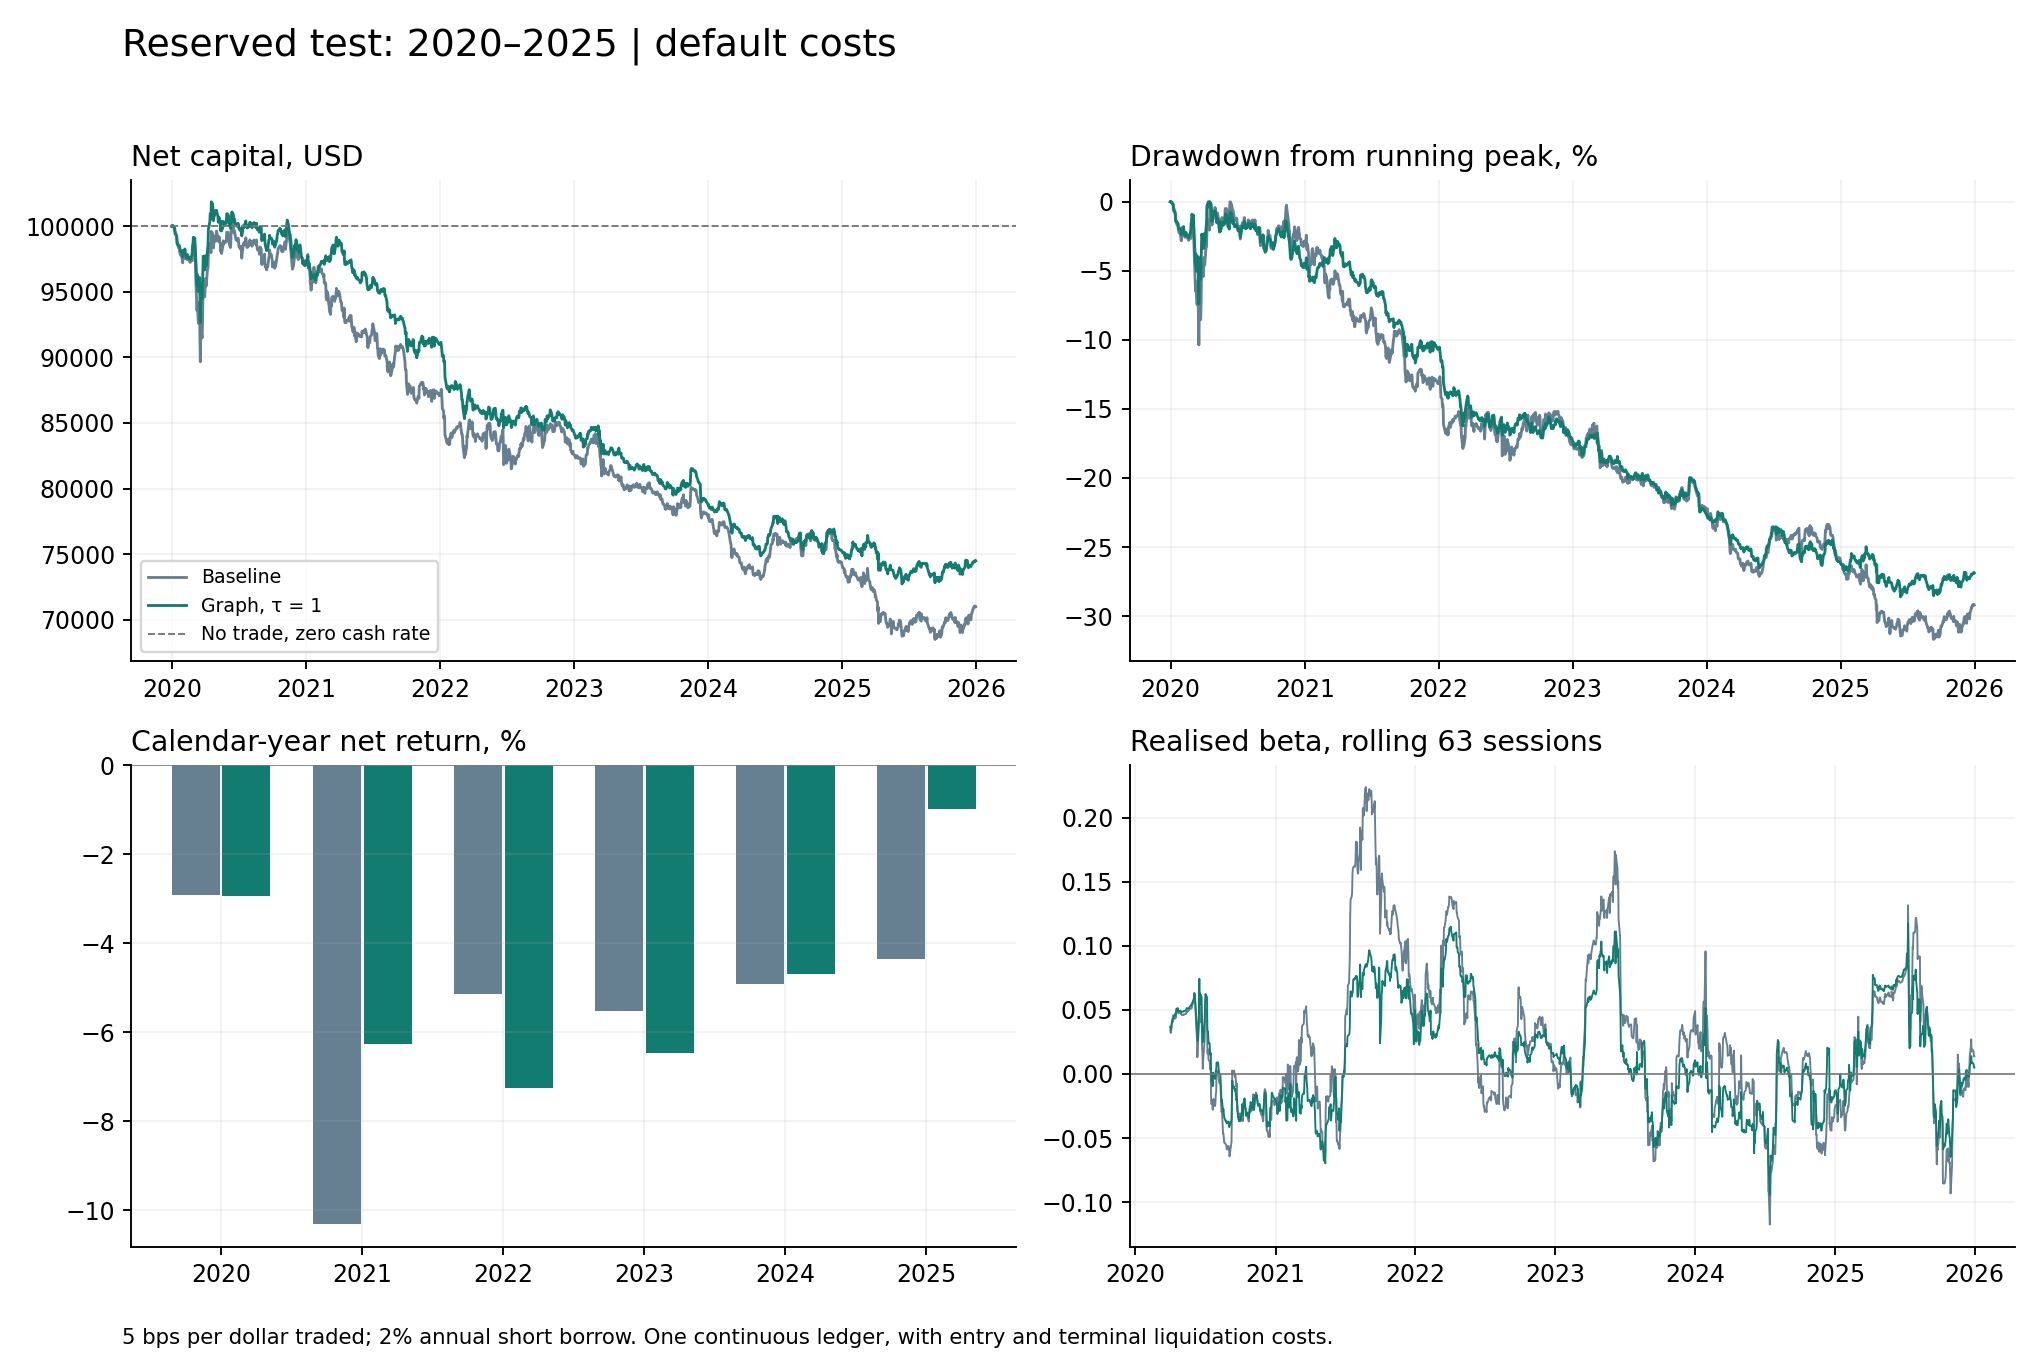

# Milestone 5 — Final evaluation

The local protocol was locked before acquisition of the reserved 2020–2025 observations. All 22 declared cases were evaluated; no primary model or parameter was changed after results. The test is now observed.

## Primary outcomes

| Measure | Baseline | Graph, τ = 1 |
| --- | ---: | ---: |
| CAGR | -5.57% | -4.80% |
| Total net return | -29.02% | -25.52% |
| Maximum drawdown | -31.69% | -28.61% |
| Annualised volatility | 5.97% | 4.66% |
| Mean gross exposure | 66.12% | 63.48% |
| Mean daily turnover | 41.69% | 41.08% |

Defaults: 5 bps per dollar traded, 2% annual short borrow. Both strategies lost money in every calendar year of the test.

The annualised arithmetic graph-minus-baseline mean is **+0.73 pp**. Its 95% pointwise interval is **-1.66 to +3.25 pp**; the Bonferroni-adjusted interval is **-2.14 to +3.85 pp**. These are arithmetic-mean intervals, not CAGR intervals.

None of the four predeclared evidence conditions was met. A smaller observed loss does not establish a positive or reliably superior strategy. Matched-gross controls also leave the paired improvement uncertain.

## Why the economic result is negative

Baseline: annualised arithmetic gross contribution +0.37%, trading drag 5.25%, borrow drag 0.67%, net -5.55%.

Graph, τ = 1: annualised arithmetic gross contribution +1.00%, trading drag 5.18%, borrow drag 0.64%, net -4.81%.

## Topology remains a diagnostic

Four features at all three declared windows were extracted on 1,508 final-test dates. Development-fitted control models were transferred without refitting. The transferred primary-window H1-total and H1-maximum approximations gave final-test R² −0.217 and −0.088. H1 rankings remain window-sensitive. No topology overlay was added.

## Scope and next step

This is a retrospectively reserved survivor-basket study using current-vintage adjusted prices. It is not a prospective blind test or evidence of deployability. The inference is conditional and approximate; it does not cure sample selection or nonstationarity.

The research evaluation is complete for the frozen design. Next is the public-repository and presentation milestone, including accurate CV/LinkedIn claims and the author's final document specification. Any future model revision requires new evidence; this test cannot be reused as untouched.


In [4]:
primary = summary.loc[summary.purpose == "primary"].set_index("model")
display(primary[["annualised_return", "total_return", "annualised_volatility",
                 "maximum_drawdown", "realized_market_beta", "mean_gross_exposure"]])
display(Image(filename=str(output / "13-final-performance.png")))
display(Markdown((output / "milestone-5-results.md").read_text()))

## 4. Examine the fixed three-mean family

Politis and Romano (1994), in *The Stationary Bootstrap*, provide the dependence-preserving construction. Nordman (2009), in *A note on the stationary bootstrap's variance*, gives the finite-variance relationship used in the numerical checks. The same sampled date blocks are applied to baseline, graph and their paired difference. Newey and West (1987) provide the HAC cross-check.

$$\xi_t=(R_t^{B,\mathrm{net}},R_t^{G,\mathrm{net}},R_t^{G,\mathrm{net}}-R_t^{B,\mathrm{net}})^\top,\qquad\widehat\mu_j=252\bar\xi_j.\tag{29}$$

As Lehmann and Romano (2005) explain in *Testing Statistical Hypotheses*, individual and family-wise error are different quantities. The fixed family has three means, so each two-sided adjusted interval has nominal coverage 1−0.05/3, approximately 98.33%:

$$\Pr\!\left(\bigcup_{j=1}^{3}\{\mu_j\notin I_j\}\right)\leq\sum_{j=1}^{3}\Pr(\mu_j\notin I_j)\leq0.05.\tag{30}$$

This is an approximate joint-coverage design because the marginal intervals are approximate. It does not correct survivor selection, structural change or unlimited earlier searches. The estimand is an annualised **arithmetic mean**, not CAGR. All block lengths and both reporting levels remain in the CSV.

def fixed_family_intervals(paired, settings):
    if (not paired.index.is_unique or not paired.index.is_monotonic_increasing
            or not np.isfinite(paired[["baseline","graph"]].to_numpy()).all()):
        raise ValueError("Need finite, uniquely dated paired returns")
    base, graph = paired.baseline.to_numpy(), paired.graph.to_numpy()
    values = np.column_stack([base,graph,graph-base])
    levels = confidence_levels(settings["family_alpha"],3)
    rows, samples = [], {}
    for length in settings["block_lengths"]:
        indices = stationary_indices(len(paired),settings["stationary_bootstrap_replicates"],length,
                                     settings["seed"]+length)
        # Each column sees the same blocks; the difference is paired path by path.
        means = np.column_stack([values[:,j][indices].mean(axis=1) for j in range(3)])
        np.testing.assert_allclose(means[:,2],means[:,1]-means[:,0],atol=1e-15)
        if length == settings["primary_block_length"]:
 

,contrast,method,block_or_lags,interval_type,confidence_level,annualised_mean,annualised_lower,annualised_upper,annualised_standard_error
6,baseline_net_mean,stationary bootstrap,10,pointwise,0.950000,-0.055483,-0.102139,-0.007984,0.023819
7,baseline_net_mean,stationary bootstrap,10,bonferroni,0.983333,-0.055483,-0.112352,0.003243,0.023819
8,graph_net_mean,stationary bootstrap,10,pointwise,0.950000,-0.048145,-0.084365,-0.010757,0.018658
9,graph_net_mean,stationary bootstrap,10,bonferroni,0.983333,-0.048145,-0.093241,-0.001447,0.018658
10,graph_minus_baseline_mean,stationary bootstrap,10,pointwise,0.950000,0.007338,-0.016607,0.032451,0.012494
11,graph_minus_baseline_mean,stationary bootstrap,10,bonferroni,0.983333,0.007338,-0.021380,0.038511,0.012494


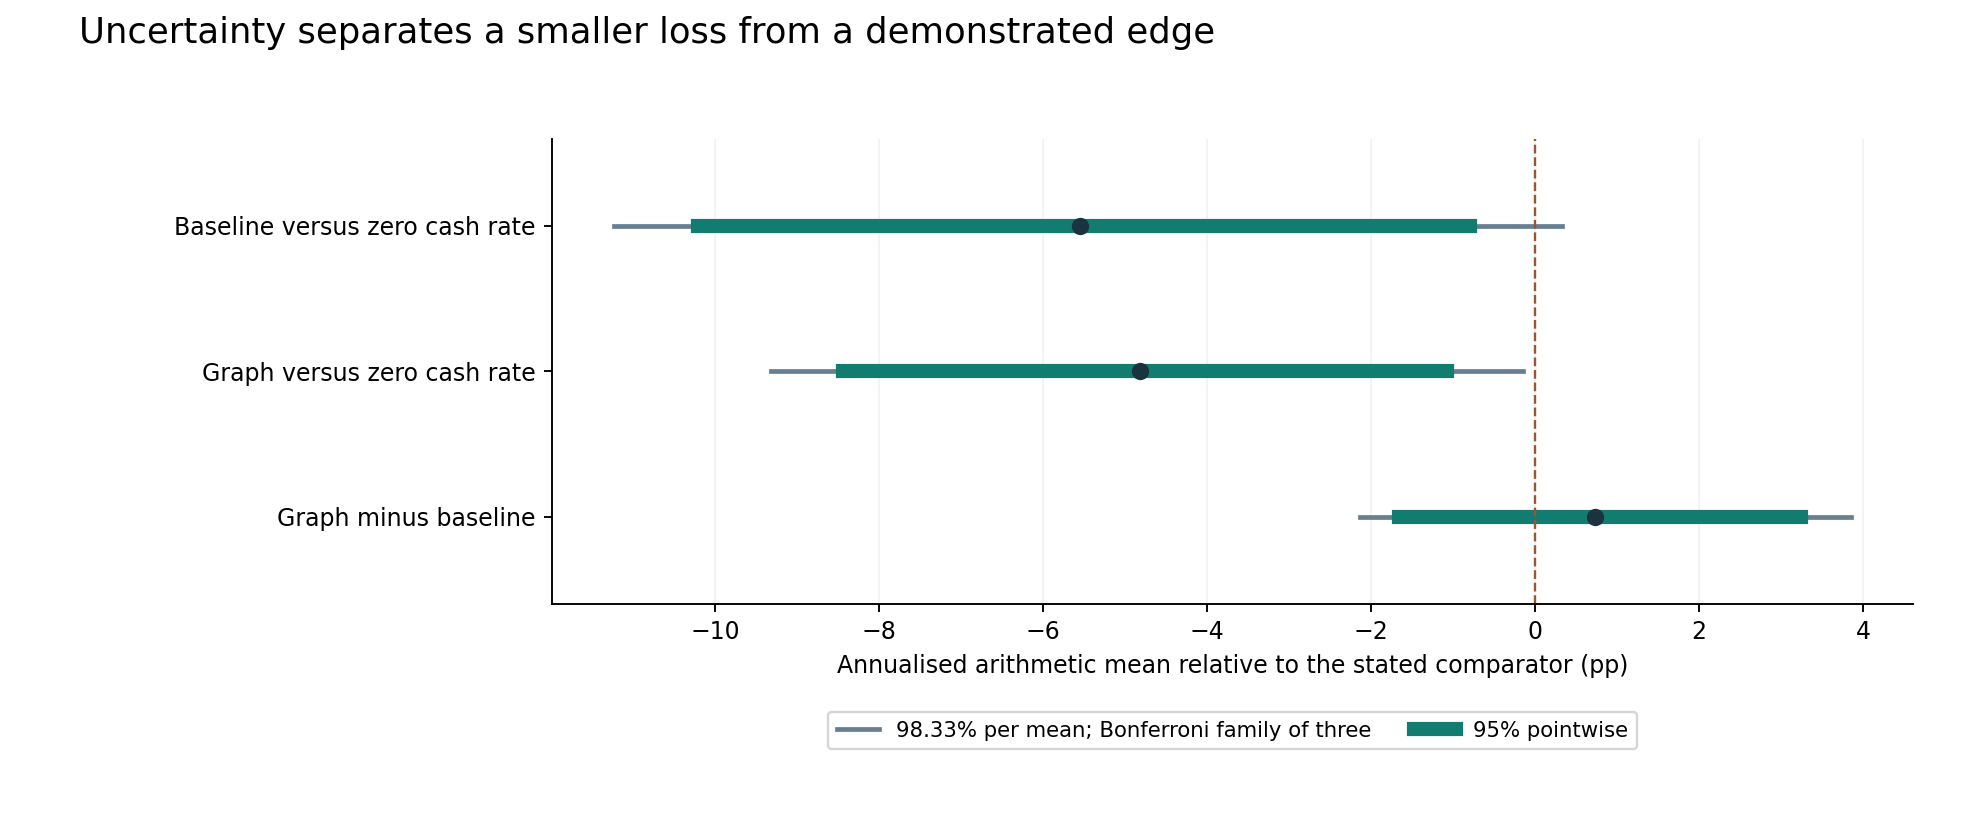

In [5]:
display(intervals.loc[(intervals.method == "stationary bootstrap") &
                      (intervals.block_or_lags == 10)])
samples = pd.read_csv(output / "primary-bootstrap-means.csv")
np.testing.assert_allclose(samples.graph_minus_baseline_mean,
                           samples.graph_net_mean-samples.baseline_net_mean, atol=2e-14)
print(inspect.getsource(fixed_family_intervals))
display(Image(filename=str(output / "14-final-inference.png")))
print(json.dumps(manifest["evidence_gate"], indent=2))

## 5. Keep the exposure, cost and annual controls

Matched gross reduces both decision portfolios to the smaller original gross before the execution delay. It does not equalise all risks. Its paired interval still includes zero. The fee and borrow cases are sensitivities, not candidates to promote after the result.

The arithmetic gross contribution minus trading and borrow drag reconciles with the arithmetic net mean. It is not a decomposition of CAGR. Annual returns compound within one continuous ledger, without resets or excluded years.

,model,annualised_return,mean_gross_exposure,mean_turnover
20,baseline_matched,-0.049419,0.595733,0.379733
21,graph_matched,-0.046936,0.595733,0.386037


,contrast,method,block_or_lags,confidence_level,annualised_mean,annualised_lower,annualised_upper
0,matched_graph_minus_baseline,stationary bootstrap,10,0.95,0.002105,-0.019697,0.024393
1,matched_graph_minus_baseline,Newey-West HAC,10,0.95,0.002105,-0.019434,0.023644


trading_cost_bps,0.0,5.0,10.0,20.0
model,,,,
baseline,-0.004720,-0.055661,-0.103995,-0.193369
baseline_matched,NaN,-0.049419,NaN,NaN
graph_matched,NaN,-0.046936,NaN,NaN
graph_tau_0.5,0.003925,-0.046177,-0.093778,-0.181973
graph_tau_1,0.002529,-0.048041,-0.096061,-0.184956
graph_tau_2,-0.000609,-0.051269,-0.099361,-0.188357


model,baseline,graph_tau_1
year,,
2020,-0.029165,-0.029350
2021,-0.102961,-0.062620
2022,-0.051364,-0.072601
2023,-0.055207,-0.064547
2024,-0.049081,-0.046938
2025,-0.043633,-0.009944


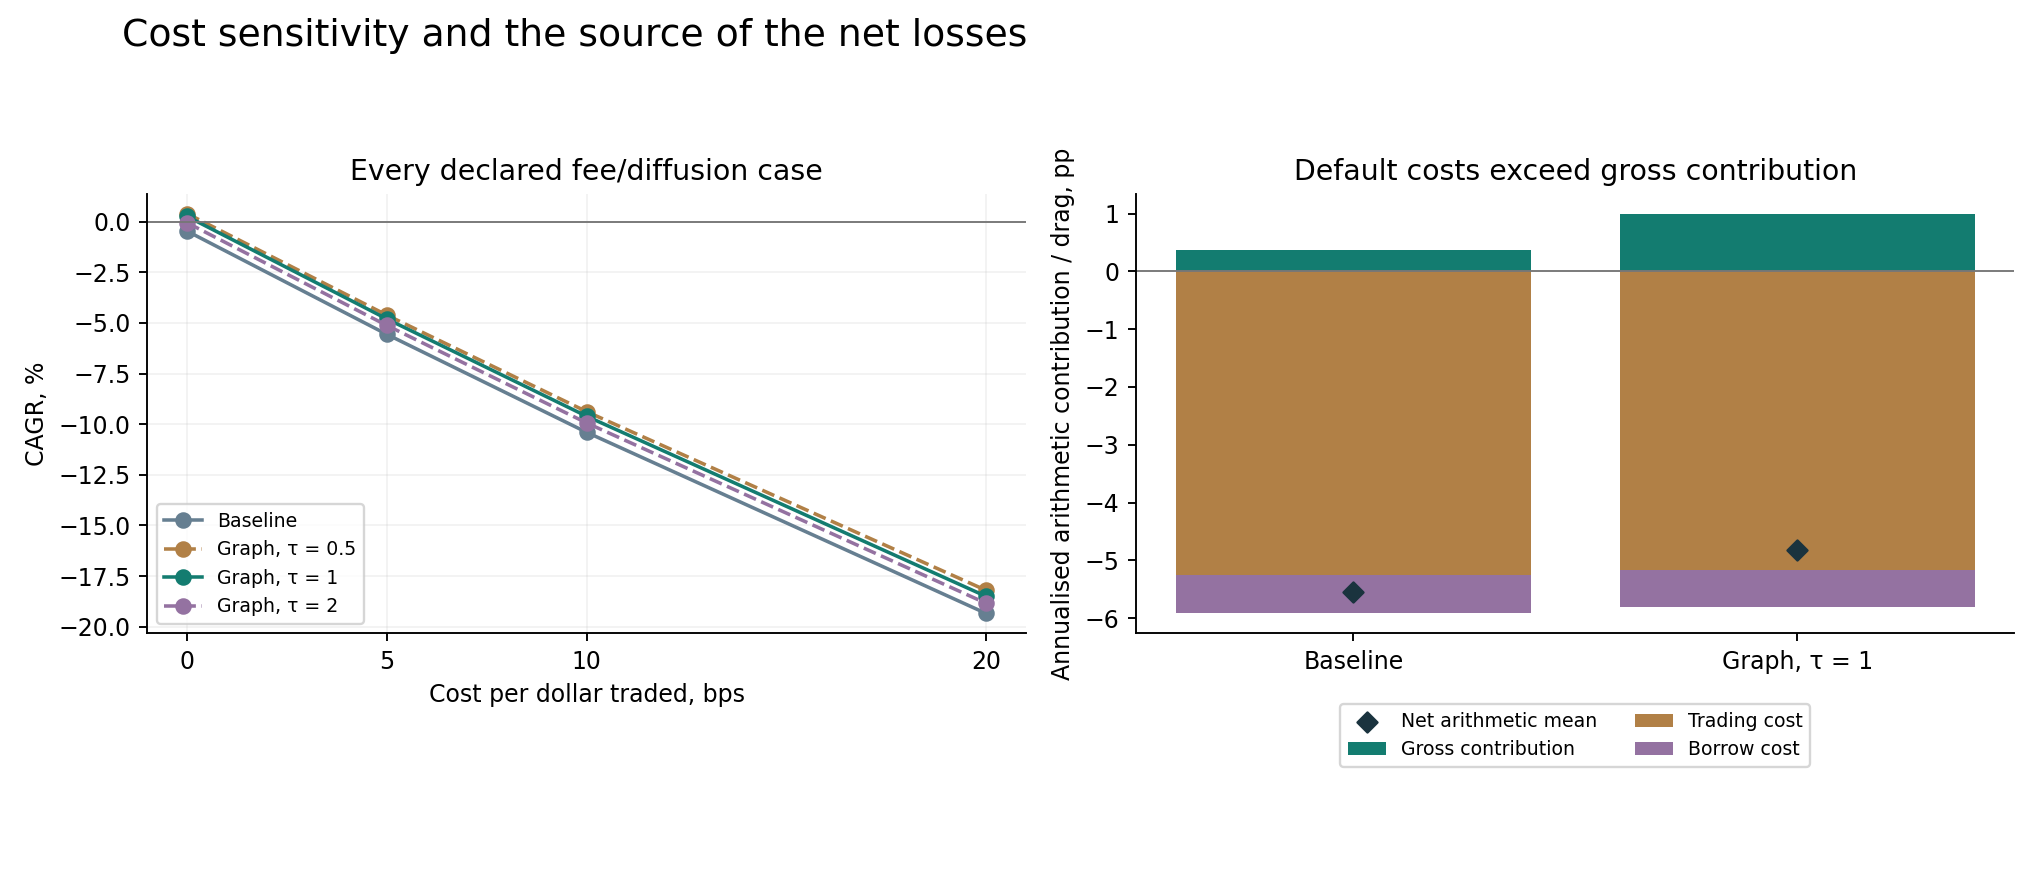

In [6]:
display(summary.loc[summary.purpose == "matched gross control",
                    ["model", "annualised_return", "mean_gross_exposure", "mean_turnover"]])
display(pd.read_csv(output / "matched-uncertainty.csv"))
display(summary.loc[summary.annual_borrow_rate == .02].pivot(
    index="model", columns="trading_cost_bps", values="annualised_return"))
annual = pd.read_csv(output / "calendar-year-results.csv")
display(annual.pivot(index="year", columns="model", values="net_return"))
for model in ["baseline", "graph_tau_1"]:
    np.testing.assert_allclose((1+annual.loc[annual.model == model, "net_return"]).prod()-1,
                               primary.loc[model, "total_return"], atol=1e-11)
display(Image(filename=str(output / "15-final-costs.png")))

## 6. Transfer topology controls without refitting

All four descriptors are extracted at 63, 126 and 252 sessions. The saved development-only means, scales and coefficients are reused unchanged. Negative final R² indicates that this fixed approximation transfers poorly relative to the phase-mean benchmark; it does not prove profitable information in the residuals.

As Chazal et al. (2014) explain in *Persistence stability for geometric complexes*, metric perturbations control diagram changes. Passing that bound is distinct from stable cross-window rankings or a transferable statistical relationship.

def final_topology(root, dataset, protocol):
    """Transfer frozen descriptor/control relationships; no final-period fitting."""
    root = Path(root)
    if version("ripser") != "0.6.14":
        raise ValueError("Install the pinned Ripser version")
    returns, market = simple_returns(dataset)
    start, end = protocol["test_period"]
    dates = returns.loc[start:end].index
    monthly = pd.Series(dates,index=dates).resample("ME").last().dropna()
    settings = protocol["topology_transfer"]
    frame,snapshots,distances = rolling_features(returns,market,settings["windows"],dates,monthly)
    models = json.loads((root / "outputs/topology/control-models.json").read_text())
    scores, correlations, predictions, stability = [], [], [], []
    for window in settings["windows"]:
        data = frame.loc[frame.window == window]
        for feature in FEATURES:
            model = models[f"{window}|{feature}"]
            if model["fitted_last_date"] >= "2017-01-01":
                raise 

window,63,126,252
feature,,,
h0_max,0.455112,0.693618,-0.513706
h0_mean,0.641533,0.419612,-0.230270
h1_max,0.143344,-0.088059,-0.032349
h1_total,0.261106,-0.217024,0.080800


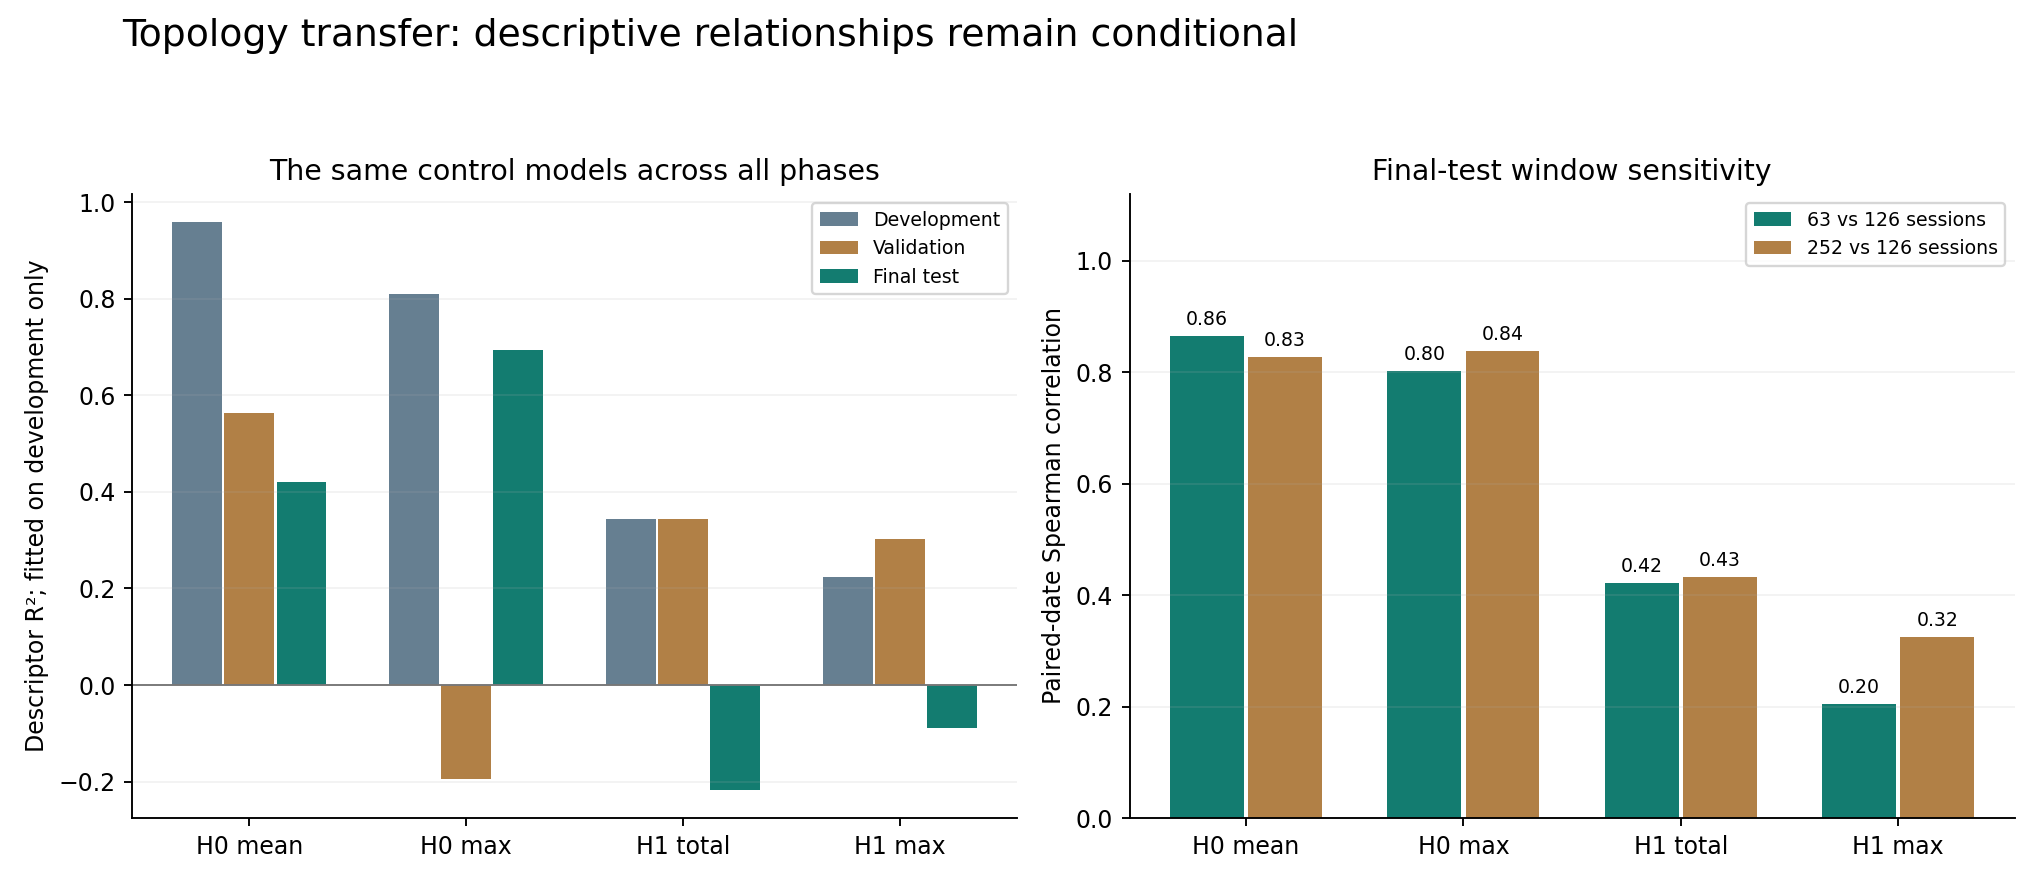

In [7]:
assert sha256(ROOT / "outputs/topology/control-models.json") == protocol["topology_control_models_sha256"]
assert manifest["topology"]["control_models_refitted"] is False
features = pd.read_csv(output / "topology/features.csv", index_col="date", parse_dates=True)
scores = pd.read_csv(output / "topology/control-model-scores.csv")
checks = pd.read_csv(output / "topology/diagram-stability.csv")
assert len(features) == 4524 and len(checks) == 288
assert (checks.bottleneck_distance <= checks.max_distance_change + 2e-6).all()
display(scores.pivot(index="feature", columns="window", values="r2"))
print(inspect.getsource(final_topology))
display(Image(filename=str(output / "16-final-topology-transfer.png")))

## 7. Explore the 72 monthly landscapes

As Bubenik (2015) explains in *Statistical topological data analysis using persistence landscapes*, interval lifetimes can be represented by ordered tent functions. The HTML companion pairs five landscape layers with the actual birth/death diagram at each monthly close. All finite intervals enter the descriptor calculation even when more than five overlap.

Open the file in a browser to rotate, hover, move the date slider or play the sequence. Axes are fixed across frames; the surface between integer ranks is visual interpolation. A peak is not a crash probability or a trade recommendation. Numerical frame/configuration verification does not imply browser interaction was tested here.

In [8]:
explorer = output / "topology/Final-Test-Landscape-Explorer.html"
figure = json.loads((output / "topology/explorer-figure.json").read_text())
assert len(figure["frames"]) == 72
assert len(figure["layout"]["sliders"][0]["steps"]) == 72
print("Frames:", len(figure["frames"]), "from", figure["frames"][0]["name"], "to", figure["frames"][-1]["name"])
display(Markdown("[Open the offline final-test 3D companion](../outputs/final/topology/Final-Test-Landscape-Explorer.html)"))

Frames: 72 from 2020-01-31 to 2025-12-31


[Open the offline final-test 3D companion](../outputs/final/topology/Final-Test-Landscape-Explorer.html)

## 8. Record the setbacks and stop selecting on this test

The decision log covers all five milestones. This stage records the no-overlay fork, adjusted-price vintage audit, absolute-versus-relative inference, failed economic evidence conditions, poor topology-model transfer and the empty-ledger repair. The negative hypothesis remains negative.

The research evaluation is complete for this design. The next milestone prepares the public repository and accurate CV/LinkedIn presentation, with the final PDF waiting for the author's style specification. Any future strategy revision requires new evidence; this period is permanently observed.

In [9]:
decision_log = (ROOT / "docs/milestone-decisions.md").read_text()
for milestone in range(1,6):
    assert f"## Milestone {milestone}" in decision_log
assert manifest["test_is_now_observed"] and not manifest["post_test_model_selection"]
assert not any(manifest["evidence_gate"]["conditions"].values())
print("Problem-solving records cover all five completed milestones.")
print("No primary-model retuning. Final test now observed. Final PDF deferred.")

Problem-solving records cover all five completed milestones.
No primary-model retuning. Final test now observed. Final PDF deferred.


## 9. Run the focused engineering checks

The suite checks causal execution, ledger accounting, numerical projection, graph and persistence relationships, paired uncertainty, vintage comparisons and the evidence gate. A passing engineering check establishes none of the economic claims by itself.

In [10]:
import subprocess
check = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
                       cwd=ROOT, capture_output=True, text=True)
log = check.stdout + check.stderr
(ROOT / "validation/milestone-5-tests.txt").write_text(log)
print(log)
assert check.returncode == 0

test_circular_continuation_and_constant_series (test_comparison.ComparisonChecks.test_circular_continuation_and_constant_series) ... ok
test_frozen_comparison_protocol_rejects_edits (test_comparison.ComparisonChecks.test_frozen_comparison_protocol_rejects_edits) ... ok
test_hac_matches_bartlett_quadratic_form (test_comparison.ComparisonChecks.test_hac_matches_bartlett_quadratic_form) ... ok
test_matching_gross_preserves_neutrality_and_never_levers_up (test_comparison.ComparisonChecks.test_matching_gross_preserves_neutrality_and_never_levers_up) ... ok
test_paired_mean_interval_is_translation_equivariant (test_comparison.ComparisonChecks.test_paired_mean_interval_is_translation_equivariant) ... ok
test_stationary_bootstrap_matches_exact_mean_variance (test_comparison.ComparisonChecks.test_stationary_bootstrap_matches_exact_mean_variance) ... ok
test_bonferroni_tail_budget_is_the_declared_family_alpha (test_final.FinalEvaluationTests.test_bonferroni_tail_budget_is_the_declared_family_alp

## References

Bailey, D.H., Borwein, J.M., Lopez de Prado, M. and Zhu, Q.J. (2017) ‘The probability of backtest overfitting’, *The Journal of Computational Finance*, 20(4), pp. 39–69. doi: [10.21314/JCF.2016.322](https://doi.org/10.21314/JCF.2016.322).

Bubenik, P. (2015) ‘Statistical topological data analysis using persistence landscapes’, *Journal of Machine Learning Research*, 16(3), pp. 77–102. Available at: [https://jmlr.org/papers/v16/bubenik15a.html](https://jmlr.org/papers/v16/bubenik15a.html) (Accessed: 21 September 2026).

Chazal, F., de Silva, V. and Oudot, S. (2014) ‘Persistence stability for geometric complexes’, *Geometriae Dedicata*, 173(1), pp. 193–214. doi: [10.1007/s10711-013-9937-z](https://doi.org/10.1007/s10711-013-9937-z).

Lehmann, E.L. and Romano, J.P. (2005) *Testing Statistical Hypotheses*. 3rd edn. Springer Texts in Statistics. Springer. doi: [10.1007/0-387-27605-X](https://doi.org/10.1007/0-387-27605-X).

Newey, W.K. and West, K.D. (1987) ‘A Simple, Positive Semi-Definite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix’, *Econometrica*, 55(3), pp. 703–708. doi: [10.2307/1913610](https://doi.org/10.2307/1913610).

Nordman, D.J. (2009) ‘A note on the stationary bootstrap's variance’, *The Annals of Statistics*, 37(1), pp. 359–370. doi: [10.1214/07-AOS567](https://doi.org/10.1214/07-AOS567).

Politis, D.N. and Romano, J.P. (1994) ‘The Stationary Bootstrap’, *Journal of the American Statistical Association*, 89(428), pp. 1303–1313. doi: [10.1080/01621459.1994.10476870](https://doi.org/10.1080/01621459.1994.10476870).

Shumway, T. (1997) ‘The Delisting Bias in CRSP Data’, *The Journal of Finance*, 52(1), pp. 327–340. doi: [10.1111/j.1540-6261.1997.tb03818.x](https://doi.org/10.1111/j.1540-6261.1997.tb03818.x).

White, H. (2000) ‘A Reality Check for Data Snooping’, *Econometrica*, 68(5), pp. 1097–1126. doi: [10.1111/1468-0262.00152](https://doi.org/10.1111/1468-0262.00152).

Yahoo Finance (2026b) *Historical daily chart responses for the declared stock basket and SPY, 2018–2025*. Available at: [https://query1.finance.yahoo.com/v8/finance/chart/SPY?period1=1546214400&period2=1767225600&interval=1d&events=div%2Csplits](https://query1.finance.yahoo.com/v8/finance/chart/SPY?period1=1546214400&period2=1767225600&interval=1d&events=div%2Csplits) (Accessed: 22 September 2026).